# Equities

## Exercise 1: Calculating Returns

In [2]:
import pandas as pd

appl_price = pd.read_excel("../data/equity_data.xlsx", sheet_name="prices AAPL")
appl_corpacts = pd.read_excel("../data/equity_data.xlsx", sheet_name="dividends AAPL")


In [3]:
appl_corpacts.columns

Index(['record_date', 'declared_date', 'ex_date', 'payable_date',
       'dividend_amount', 'dividend_frequency', 'dividend_type'],
      dtype='str')

In [4]:
dates = appl_corpacts.loc[appl_corpacts['dividend_type']=="Regular Cash", 'ex_date']
amounts = appl_corpacts.loc[appl_corpacts['dividend_type']=="Regular Cash", 'dividend_amount']

In [5]:
appl_price.columns

Index(['date', 'Adjusted Price', 'Unadjusted Price'], dtype='str')

In [6]:
list(appl_price.index[appl_price["date"]==dates[0]])[0]

5623

In [7]:
full_df = pd.merge(appl_price, appl_corpacts, how="outer", left_on="date", right_on="ex_date").sort_values("date", ascending=False).reset_index(drop=True)

In [8]:
full_df["shift_adj_price"] = full_df["Adjusted Price"].shift(-1)
full_df["shift_unadj_price"] = full_df["Unadjusted Price"].shift(-1)
full_df.head()

,date,Adjusted Price,Unadjusted Price,record_date,declared_date,ex_date,payable_date,dividend_amount,dividend_frequency,dividend_type,shift_adj_price,shift_unadj_price
0,2026-06-09,290.55,290.55,NaT,NaT,NaT,NaT,NaN,NaN,NaN,301.54,301.54
1,2026-06-08,301.54,301.54,NaT,NaT,NaT,NaT,NaN,NaN,NaN,307.34,307.34
2,2026-06-05,307.34,307.34,NaT,NaT,NaT,NaT,NaN,NaN,NaN,311.23,311.23
3,2026-06-04,311.23,311.23,NaT,NaT,NaT,NaT,NaN,NaN,NaN,310.26,310.26
4,2026-06-03,310.26,310.26,NaT,NaT,NaT,NaT,NaN,NaN,NaN,315.20,315.20


In [9]:
full_df.loc[~full_df["ex_date"].isna()].head()
man_ret_div = (full_df.loc[~full_df["ex_date"].isna(), ["Unadjusted Price", "dividend_amount"]].sum(axis=1) / full_df.loc[~full_df["ex_date"].isna(), "shift_unadj_price"])-1
adj_ret_div = (full_df.loc[~full_df["ex_date"].isna(), "Adjusted Price"] / full_df.loc[~full_df["ex_date"].isna(), "shift_adj_price"])-1

print(man_ret_div.head(), "\n",  adj_ret_div.head())

20    -0.001261
83    -0.011650
144    0.004544
208   -0.008328
270    0.063064
dtype: float64 
 20    -0.001263
83    -0.011660
144    0.004548
208   -0.008337
270    0.063147
dtype: float64


In [10]:
man_return = []
adj_return = []
for amount, date in list(zip(amounts, dates))[:2]:
    loc = list(appl_price.index[appl_price["date"]==date])[0]
    man_ret = (appl_price['Unadjusted Price'].iloc[loc]+amount)/appl_price['Unadjusted Price'].iloc[loc-1] if loc > 0 else 0
    man_return.append(round(man_ret,5))
    adj_ret = (appl_price['Adjusted Price'].iloc[loc])/appl_price['Adjusted Price'].iloc[loc-1] if loc > 0 else 0
    adj_return.append(round(adj_ret,5))
    # rounds+=1

In [11]:
print(man_return, adj_return)

[np.float64(0.99874), np.float64(0.98835)] [np.float64(0.99874), np.float64(0.98834)]


In [12]:
appl_corpacts.columns

Index(['record_date', 'declared_date', 'ex_date', 'payable_date',
       'dividend_amount', 'dividend_frequency', 'dividend_type'],
      dtype='str')

In [13]:
appl_corpacts["dividend_type"].unique()

<StringArray>
['Regular Cash', 'Stock Split', 'Discontinued']
Length: 3, dtype: str

In [14]:
split_events = appl_corpacts.loc[appl_corpacts["dividend_type"]=="Stock Split", :].reset_index(drop=True)

In [15]:
split_events

,record_date,declared_date,ex_date,payable_date,dividend_amount,dividend_frequency,dividend_type
0,2020-08-24,2020-07-30,2020-08-31,2020-08-28,4.0,NaN,Stock Split
1,2014-06-02,2014-04-23,2014-06-09,2014-06-06,7.0,NaN,Stock Split
2,2005-02-18,2005-02-11,2005-02-28,2005-02-25,2.0,NaN,Stock Split
3,2000-05-19,2000-04-19,2000-06-21,2000-06-20,2.0,NaN,Stock Split
4,1987-05-15,1987-04-22,1987-06-16,1987-06-15,2.0,NaN,Stock Split


In [16]:
pos = list(appl_price.index[appl_price["date"]==split_events.loc[0, "ex_date"]])[0]

In [17]:
man_ret_split = appl_price.loc[pos, "Unadjusted Price"]*split_events.loc[0, "dividend_amount"]/appl_price.loc[pos-1, "Unadjusted Price"]
adj_ret_split = appl_price.loc[pos, "Adjusted Price"]/appl_price.loc[pos-1, "Adjusted Price"]
print(man_ret_split, adj_ret_split)

1.0339122248262322 1.0339120256599397


In [18]:
full_df.loc[full_df["dividend_type"]=="Stock Split"].dropna(subset=["date"])

split_events = full_df.loc[full_df["dividend_type"]=="Stock Split"].dropna(subset=["date"])
man_ret_split = split_events["Unadjusted Price"]*split_events["dividend_amount"]/split_events["shift_unadj_price"]
adj_ret_split = split_events["Adjusted Price"]/split_events["shift_adj_price"]
pd.concat([man_ret_split, adj_ret_split], axis=1).rename(columns={0:"manual", 1:"adjusted"})

,manual,adjusted
1449,1.033912,1.033912
3018,1.016001,1.016000
5353,1.008203,1.008183


## Exercise 2: Stock Sensiticity

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
etf_df = pd.read_excel("../data/equity_data.xlsx", sheet_name="etf history")
etf_df.head()

,date,SPY,UPRO,EEM,VGK,EWJ,IYR,DBC,HYG,TIP,BITO
0,1993-01-29,24.1807,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1993-02-01,24.3527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1993-02-02,24.4043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1993-02-03,24.6622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1993-02-04,24.7654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
etf_df = etf_df.set_index("date", drop=True)
etf_df.head()

,SPY,UPRO,EEM,VGK,EWJ,IYR,DBC,HYG,TIP,BITO
date,,,,,,,,,,
1993-01-29,24.1807,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-01,24.3527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-02,24.4043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-03,24.6622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-04,24.7654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
etf_df.corr()

,SPY,UPRO,EEM,VGK,EWJ,IYR,DBC,HYG,TIP,BITO
SPY,1.000000,0.977206,0.811212,0.967546,0.931607,0.916068,0.008005,0.925156,0.838004,0.823945
UPRO,0.977206,1.000000,0.881603,0.964347,0.953047,0.866270,0.232304,0.898436,0.838877,0.802206
EEM,0.811212,0.881603,1.000000,0.895941,0.861063,0.846201,0.085148,0.831568,0.861820,0.609855
VGK,0.967546,0.964347,0.895941,1.000000,0.974050,0.912418,0.056812,0.905470,0.804768,0.755894
EWJ,0.931607,0.953047,0.861063,0.974050,1.000000,0.914443,-0.038625,0.909381,0.773140,0.720431
IYR,0.916068,0.866270,0.846201,0.912418,0.914443,1.000000,-0.183142,0.965599,0.908332,0.632135
DBC,0.008005,0.232304,0.085148,0.056812,-0.038625,-0.183142,1.000000,-0.212230,-0.177535,0.016105
HYG,0.925156,0.898436,0.831568,0.905470,0.909381,0.965599,-0.212230,1.000000,0.956185,0.859987
TIP,0.838004,0.838877,0.861820,0.804768,0.773140,0.908332,-0.177535,0.956185,1.000000,0.642790
BITO,0.823945,0.802206,0.609855,0.755894,0.720431,0.632135,0.016105,0.859987,0.642790,1.000000


<Axes: >

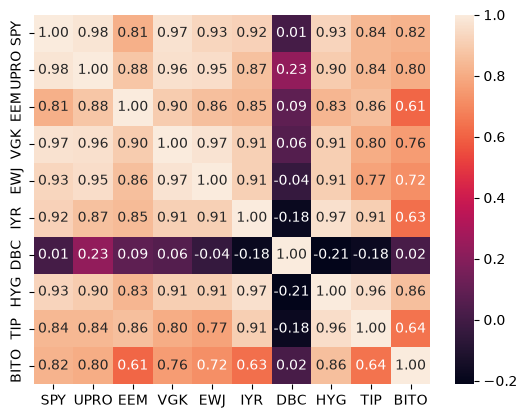

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(etf_df.corr(), annot=True, fmt=".2f")

In [24]:
intersect = etf_df[["UPRO"]].index.intersection(etf_df["SPY"].index)
intersect

DatetimeIndex(['1993-01-29', '1993-02-01', '1993-02-02', '1993-02-03',
               '1993-02-04', '1993-02-05', '1993-02-08', '1993-02-09',
               '1993-02-10', '1993-02-11',
               ...
               '2026-05-27', '2026-05-28', '2026-05-29', '2026-06-01',
               '2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05',
               '2026-06-08', '2026-06-09'],
              dtype='datetime64[us]', name='date', length=8397, freq=None)

In [25]:
etf_df[["UPRO"]].dropna()

,UPRO
date,
2009-06-25,1.1324
2009-06-26,1.1265
2009-06-29,1.1585
2009-06-30,1.1308
2009-07-01,1.1429
...,...
2026-06-03,147.7200
2026-06-04,149.3300
2026-06-05,137.5300


In [26]:
for col in etf_df.columns:
    model = LinearRegression()
    intersect = etf_df[[col]].dropna().index.intersection(etf_df["SPY"].dropna().index)
    model.fit(etf_df.loc[intersect, [col]], etf_df.loc[intersect, "SPY"]) # sklearn automatically add constant in front
    print(f"for {col}, the coefficients are {model.coef_}, and intercept is {model.intercept_}")

# this is wrong since what we're looking for is the model for returns

for SPY, the coefficients are [1.], and intercept is -1.1368683772161603e-13
for UPRO, the coefficients are [5.37070018], and intercept is 116.1942768661616
for EEM, the coefficients are [13.08241572], and intercept is -190.94460307530747
for VGK, the coefficients are [11.02065159], and intercept is -221.32020289725153
for EWJ, the coefficients are [10.77530375], and intercept is -245.59883826983588
for IYR, the coefficients are [5.84734409], and intercept is -85.9174490312804
for DBC, the coefficients are [0.26921821], and intercept is 237.4643985178439
for HYG, the coefficients are [11.23796862], and intercept is -330.6702201732494
for TIP, the coefficients are [8.20968874], and intercept is -445.1008305455431
for BITO, the coefficients are [22.24647101], and intercept is 310.36981537345997


In [27]:
for col in etf_df.columns:
    model = LinearRegression()
    intersect = etf_df[[col]].pct_change().dropna().index.intersection(etf_df["SPY"].pct_change().dropna().index)
    model.fit(etf_df[[col]].pct_change().dropna().loc[intersect], etf_df["SPY"].pct_change().dropna().loc[intersect]) # sklearn automatically add constant in front
    print(f"for {col}, the coefficients are {model.coef_}, and intercept is {model.intercept_}")



for SPY, the coefficients are [1.], and intercept is 1.0299920638612292e-18
for UPRO, the coefficients are [0.33342151], and intercept is 6.501249707792161e-05
for EEM, the coefficients are [0.55182113], and intercept is 0.00021585073823159257
for VGK, the coefficients are [0.71237497], and intercept is 0.00023555964654963212
for EWJ, the coefficients are [0.55080262], and intercept is 0.000345595094295347
for IYR, the coefficients are [0.52281916], and intercept is 0.00014319496164289235
for DBC, the coefficients are [0.39180055], and intercept is 0.00043194679407427855
for HYG, the coefficients are [1.23310693], and intercept is 0.0002227646655589617
for TIP, the coefficients are [-0.29514373], and intercept is 0.0005260738849027107
for BITO, the coefficients are [0.13802201], and intercept is 0.0004878711213927478


# Trading Value Stocks

## Exercise 1: A value strategy

### Data Exploration

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
equity = pd.read_excel("../data/spx_data_weekly.xlsx", sheet_name="spx data", header=None)
equity.head()

,0,1,2,3,4,5,6,7,8,9,...,1500,1501,1502,1503,1504,1505,1506,1507,1508,1509
0,NaN,A,NaN,NaN,AAPL,NaN,NaN,ABBV,NaN,NaN,...,NaN,ZBH,NaN,NaN,ZBRA,NaN,NaN,ZTS,NaN,NaN
1,NaN,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,...,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO
2,date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-07-03 00:00:00,36.1871,1.1054,27.308,28.2065,1.8435,13.035,43.5502,4.6843,11.7314,...,18.4056,95.8138,0.9184,18.1514,112.43,NaN,151.5166,44.1218,0.7525,26.5871
4,2015-07-10 00:00:00,36.0225,1.1104,27.1839,27.5016,1.8908,12.7092,44.2014,4.6152,11.9068,...,18.2669,94.5917,0.9303,17.9199,109.75,NaN,147.9049,42.8888,0.7741,25.8441


In [30]:
equity.iloc[0] = equity.iloc[0].ffill()
cols = ["date" if equity.iloc[2, i]=="date" else equity.iloc[0, i]+"_"+equity.iloc[1, i] for i in range(equity.shape[1])]
equity.columns=cols
equity.drop([0,1,2], axis=0)

,date,A_PX_LAST,A_EQY_DVD_YLD_IND,A_PE_RATIO,AAPL_PX_LAST,AAPL_EQY_DVD_YLD_IND,AAPL_PE_RATIO,ABBV_PX_LAST,ABBV_EQY_DVD_YLD_IND,ABBV_PE_RATIO,...,YUM_PE_RATIO,ZBH_PX_LAST,ZBH_EQY_DVD_YLD_IND,ZBH_PE_RATIO,ZBRA_PX_LAST,ZBRA_EQY_DVD_YLD_IND,ZBRA_PE_RATIO,ZTS_PX_LAST,ZTS_EQY_DVD_YLD_IND,ZTS_PE_RATIO
3,2015-07-03 00:00:00,36.1871,1.1054,27.308,28.2065,1.8435,13.035,43.5502,4.6843,11.7314,...,18.4056,95.8138,0.9184,18.1514,112.43,NaN,151.5166,44.1218,0.7525,26.5871
4,2015-07-10 00:00:00,36.0225,1.1104,27.1839,27.5016,1.8908,12.7092,44.2014,4.6152,11.9068,...,18.2669,94.5917,0.9303,17.9199,109.75,NaN,147.9049,42.8888,0.7741,25.8441
5,2015-07-17 00:00:00,36.5253,1.0951,27.5633,28.9159,1.7983,13.3628,45.0183,4.5315,12.1268,...,17.7469,95.2028,0.9243,18.0356,114.18,NaN,153.875,43.656,0.7605,26.3064
6,2015-07-24 00:00:00,35.9402,1.113,27.1218,27.7737,1.8723,12.835,43.7898,4.6586,11.7959,...,17.5106,94.4589,0.9316,17.8947,110.89,NaN,149.4412,45.1995,0.7345,27.2365
7,2015-07-31 00:00:00,37.4396,1.0684,26.4603,27.0599,1.9217,12.5051,45.0312,4.5302,12.1303,...,17.7227,92.1651,0.9548,17.4602,107.63,NaN,145.0478,44.7337,0.7422,26.9558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,2026-06-05 00:00:00,135.18,0.7545,24.3751,307.34,0.3514,37.1632,227.23,3.0454,23.5627,...,24.2304,87.0986,1.1022,15.0239,232.11,NaN,22.5,79.44,2.6687,12.3669
574,2026-06-12 00:00:00,129.5907,0.7871,23.3673,291.13,0.371,35.2031,227.73,3.0387,23.6146,...,24.7829,88.3353,1.0868,15.2373,228.42,NaN,22.1423,79.57,2.6643,12.3871
575,2026-06-19 00:00:00,126.816,0.8043,22.867,298.01,0.3624,36.0351,216.49,3.1965,22.449,...,24.4103,87.7369,1.0942,15.134,235.98,NaN,22.8752,78.71,2.6934,12.2532
576,2026-06-26 00:00:00,135.7489,0.7514,24.4777,283.78,0.3806,34.3144,253.35,2.7314,26.2712,...,25.1201,93.1,1.0311,16.0592,251.53,NaN,24.3825,76.09,2.7862,11.8453


In [31]:
equity = equity.drop([0, 1, 2]).reset_index(drop=True)
equity.head()

,date,A_PX_LAST,A_EQY_DVD_YLD_IND,A_PE_RATIO,AAPL_PX_LAST,AAPL_EQY_DVD_YLD_IND,AAPL_PE_RATIO,ABBV_PX_LAST,ABBV_EQY_DVD_YLD_IND,ABBV_PE_RATIO,...,YUM_PE_RATIO,ZBH_PX_LAST,ZBH_EQY_DVD_YLD_IND,ZBH_PE_RATIO,ZBRA_PX_LAST,ZBRA_EQY_DVD_YLD_IND,ZBRA_PE_RATIO,ZTS_PX_LAST,ZTS_EQY_DVD_YLD_IND,ZTS_PE_RATIO
0,2015-07-03 00:00:00,36.1871,1.1054,27.308,28.2065,1.8435,13.035,43.5502,4.6843,11.7314,...,18.4056,95.8138,0.9184,18.1514,112.43,NaN,151.5166,44.1218,0.7525,26.5871
1,2015-07-10 00:00:00,36.0225,1.1104,27.1839,27.5016,1.8908,12.7092,44.2014,4.6152,11.9068,...,18.2669,94.5917,0.9303,17.9199,109.75,NaN,147.9049,42.8888,0.7741,25.8441
2,2015-07-17 00:00:00,36.5253,1.0951,27.5633,28.9159,1.7983,13.3628,45.0183,4.5315,12.1268,...,17.7469,95.2028,0.9243,18.0356,114.18,NaN,153.875,43.656,0.7605,26.3064
3,2015-07-24 00:00:00,35.9402,1.113,27.1218,27.7737,1.8723,12.835,43.7898,4.6586,11.7959,...,17.5106,94.4589,0.9316,17.8947,110.89,NaN,149.4412,45.1995,0.7345,27.2365
4,2015-07-31 00:00:00,37.4396,1.0684,26.4603,27.0599,1.9217,12.5051,45.0312,4.5302,12.1303,...,17.7227,92.1651,0.9548,17.4602,107.63,NaN,145.0478,44.7337,0.7422,26.9558


In [32]:
# since it's a weekly data => 5 years would be 5*52
YEARS = 5
WEEKS_IN_YEAR = 52

equity.isna().sum(axis=0)

date                      0
A_PX_LAST                 0
A_EQY_DVD_YLD_IND         0
A_PE_RATIO                0
AAPL_PX_LAST              0
                       ... 
ZBRA_EQY_DVD_YLD_IND    575
ZBRA_PE_RATIO            25
ZTS_PX_LAST               0
ZTS_EQY_DVD_YLD_IND       0
ZTS_PE_RATIO              0
Length: 1510, dtype: int64

In [33]:
equity.shape

(575, 1510)

In [34]:
[((equity.shape[0]-
equity[equity.columns[equity.columns.str.contains("PX_LAST")]]
.isna().sum(axis=0))>(YEARS*WEEKS_IN_YEAR))]

[A_PX_LAST       True
 AAPL_PX_LAST    True
 ABBV_PX_LAST    True
 ABNB_PX_LAST    True
 ABT_PX_LAST     True
                 ... 
 XYZ_PX_LAST     True
 YUM_PX_LAST     True
 ZBH_PX_LAST     True
 ZBRA_PX_LAST    True
 ZTS_PX_LAST     True
 Length: 503, dtype: bool]

In [35]:
names_unprocessed = equity[equity.columns[equity.columns.str.contains("PX_LAST")]].columns[((equity.shape[0]-
equity[equity.columns[equity.columns.str.contains("PX_LAST")]]
.isna().sum(axis=0))>(YEARS*WEEKS_IN_YEAR))]

In [36]:
names_processed = names_unprocessed.str.strip().str.split("_").str[0]
names_processed = set(names_processed)

In [37]:
equity_df = pd.DataFrame()
for col in equity.columns:
    if col == "date" or col.split("_")[0] in names_processed:
        equity_df[col] = equity[col]

equity_df.head()

/var/folders/3r/xyjscdhs47s9jp5p2xqww8w80000gn/T/ipykernel_54595/1800584359.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  equity_df[col] = equity[col]


,date,A_PX_LAST,A_EQY_DVD_YLD_IND,A_PE_RATIO,AAPL_PX_LAST,AAPL_EQY_DVD_YLD_IND,AAPL_PE_RATIO,ABBV_PX_LAST,ABBV_EQY_DVD_YLD_IND,ABBV_PE_RATIO,...,YUM_PE_RATIO,ZBH_PX_LAST,ZBH_EQY_DVD_YLD_IND,ZBH_PE_RATIO,ZBRA_PX_LAST,ZBRA_EQY_DVD_YLD_IND,ZBRA_PE_RATIO,ZTS_PX_LAST,ZTS_EQY_DVD_YLD_IND,ZTS_PE_RATIO
0,2015-07-03 00:00:00,36.1871,1.1054,27.308,28.2065,1.8435,13.035,43.5502,4.6843,11.7314,...,18.4056,95.8138,0.9184,18.1514,112.43,NaN,151.5166,44.1218,0.7525,26.5871
1,2015-07-10 00:00:00,36.0225,1.1104,27.1839,27.5016,1.8908,12.7092,44.2014,4.6152,11.9068,...,18.2669,94.5917,0.9303,17.9199,109.75,NaN,147.9049,42.8888,0.7741,25.8441
2,2015-07-17 00:00:00,36.5253,1.0951,27.5633,28.9159,1.7983,13.3628,45.0183,4.5315,12.1268,...,17.7469,95.2028,0.9243,18.0356,114.18,NaN,153.875,43.656,0.7605,26.3064
3,2015-07-24 00:00:00,35.9402,1.113,27.1218,27.7737,1.8723,12.835,43.7898,4.6586,11.7959,...,17.5106,94.4589,0.9316,17.8947,110.89,NaN,149.4412,45.1995,0.7345,27.2365
4,2015-07-31 00:00:00,37.4396,1.0684,26.4603,27.0599,1.9217,12.5051,45.0312,4.5302,12.1303,...,17.7227,92.1651,0.9548,17.4602,107.63,NaN,145.0478,44.7337,0.7422,26.9558


In [38]:
equity.shape

(575, 1510)

In [39]:
## an alternative method: two level indexing

equity2 = pd.read_excel("../data/spx_data_weekly.xlsx", sheet_name="spx data", header=None)
equity2.head()

,0,1,2,3,4,5,6,7,8,9,...,1500,1501,1502,1503,1504,1505,1506,1507,1508,1509
0,NaN,A,NaN,NaN,AAPL,NaN,NaN,ABBV,NaN,NaN,...,NaN,ZBH,NaN,NaN,ZBRA,NaN,NaN,ZTS,NaN,NaN
1,NaN,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,...,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO
2,date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-07-03 00:00:00,36.1871,1.1054,27.308,28.2065,1.8435,13.035,43.5502,4.6843,11.7314,...,18.4056,95.8138,0.9184,18.1514,112.43,NaN,151.5166,44.1218,0.7525,26.5871
4,2015-07-10 00:00:00,36.0225,1.1104,27.1839,27.5016,1.8908,12.7092,44.2014,4.6152,11.9068,...,18.2669,94.5917,0.9303,17.9199,109.75,NaN,147.9049,42.8888,0.7741,25.8441


In [40]:
ticker = equity2.iloc[0].ffill()
fields = equity2.iloc[1]

df = equity2.iloc[3:].copy()
df.columns = pd.MultiIndex.from_arrays([ticker, fields])
df = df.rename(columns={df.columns[0]: ("date", "date")})
df.head()

0                  nan        A                              AAPL  \
1                  nan  PX_LAST EQY_DVD_YLD_IND PE_RATIO  PX_LAST   
3  2015-07-03 00:00:00  36.1871          1.1054   27.308  28.2065   
4  2015-07-10 00:00:00  36.0225          1.1104  27.1839  27.5016   
5  2015-07-17 00:00:00  36.5253          1.0951  27.5633  28.9159   
6  2015-07-24 00:00:00  35.9402           1.113  27.1218  27.7737   
7  2015-07-31 00:00:00  37.4396          1.0684  26.4603  27.0599   

0                              ABBV                           ...      YUM  \
1 EQY_DVD_YLD_IND PE_RATIO  PX_LAST EQY_DVD_YLD_IND PE_RATIO  ... PE_RATIO   
3          1.8435   13.035  43.5502          4.6843  11.7314  ...  18.4056   
4          1.8908  12.7092  44.2014          4.6152  11.9068  ...  18.2669   
5          1.7983  13.3628  45.0183          4.5315  12.1268  ...  17.7469   
6          1.8723   12.835  43.7898          4.6586  11.7959  ...  17.5106   
7          1.9217  12.5051  45.0312          4.5302  12.1303  ...  17.7227   

0      ZBH                             ZBRA                            \
1  PX_LAST EQY_DVD_YLD_IND PE_RATIO PX_LAST EQY_DVD_YLD_IND  PE_RATIO   
3  95.8138          0.9184  18.1514  112.43             NaN  151.5166   
4  94.5917          0.9303  17.9199  109.75             NaN  147.9049   
5  95.2028          0.9243  18.0356  114.18             NaN   153.875   
6  94.4589          0.9316  17.8947  110.89             NaN  149.4412   
7  92.1651          0.9548  17.4602  107.63             NaN  145.0478   

0      ZTS                           
1  PX_LAST EQY_DVD_YLD_IND PE_RATIO  
3  44.1218          0.7525  26.5871  
4  42.8888          0.7741  25.8441  
5   43.656          0.7605  26.3064  
6  45.1995          0.7345  27.2365  
7  44.7337          0.7422  26.9558  

[5 rows x 1510 columns]

In [41]:
cols = list(df.columns)
cols[0] = ("date", "date")
df.columns = pd.MultiIndex.from_tuples(cols)
df.head()

date        A                              AAPL  \
                  date  PX_LAST EQY_DVD_YLD_IND PE_RATIO  PX_LAST   
3  2015-07-03 00:00:00  36.1871          1.1054   27.308  28.2065   
4  2015-07-10 00:00:00  36.0225          1.1104  27.1839  27.5016   
5  2015-07-17 00:00:00  36.5253          1.0951  27.5633  28.9159   
6  2015-07-24 00:00:00  35.9402           1.113  27.1218  27.7737   
7  2015-07-31 00:00:00  37.4396          1.0684  26.4603  27.0599   

                               ABBV                           ...      YUM  \
  EQY_DVD_YLD_IND PE_RATIO  PX_LAST EQY_DVD_YLD_IND PE_RATIO  ... PE_RATIO   
3          1.8435   13.035  43.5502          4.6843  11.7314  ...  18.4056   
4          1.8908  12.7092  44.2014          4.6152  11.9068  ...  18.2669   
5          1.7983  13.3628  45.0183          4.5315  12.1268  ...  17.7469   
6          1.8723   12.835  43.7898          4.6586  11.7959  ...  17.5106   
7          1.9217  12.5051  45.0312          4.5302  12.1303  ...  17.7227   

       ZBH                             ZBRA                            \
   PX_LAST EQY_DVD_YLD_IND PE_RATIO PX_LAST EQY_DVD_YLD_IND  PE_RATIO   
3  95.8138          0.9184  18.1514  112.43             NaN  151.5166   
4  94.5917          0.9303  17.9199  109.75             NaN  147.9049   
5  95.2028          0.9243  18.0356  114.18             NaN   153.875   
6  94.4589          0.9316  17.8947  110.89             NaN  149.4412   
7  92.1651          0.9548  17.4602  107.63             NaN  145.0478   

       ZTS                           
   PX_LAST EQY_DVD_YLD_IND PE_RATIO  
3  44.1218          0.7525  26.5871  
4  42.8888          0.7741  25.8441  
5   43.656          0.7605  26.3064  
6  45.1995          0.7345  27.2365  
7  44.7337          0.7422  26.9558  

[5 rows x 1510 columns]

In [42]:
keep = []
for ticker in df.columns.get_level_values(0).unique():
    if ticker == 'date':
        keep.append(ticker)
    else:
        if (df[(ticker, "PX_LAST")].notna().sum())>=(YEARS*WEEKS_IN_YEAR):
            keep.append(ticker)

processed_df = df[[col for col in df.columns if col[0] in keep]]
processed_df.head()


date        A                              AAPL  \
                  date  PX_LAST EQY_DVD_YLD_IND PE_RATIO  PX_LAST   
3  2015-07-03 00:00:00  36.1871          1.1054   27.308  28.2065   
4  2015-07-10 00:00:00  36.0225          1.1104  27.1839  27.5016   
5  2015-07-17 00:00:00  36.5253          1.0951  27.5633  28.9159   
6  2015-07-24 00:00:00  35.9402           1.113  27.1218  27.7737   
7  2015-07-31 00:00:00  37.4396          1.0684  26.4603  27.0599   

                               ABBV                           ...      YUM  \
  EQY_DVD_YLD_IND PE_RATIO  PX_LAST EQY_DVD_YLD_IND PE_RATIO  ... PE_RATIO   
3          1.8435   13.035  43.5502          4.6843  11.7314  ...  18.4056   
4          1.8908  12.7092  44.2014          4.6152  11.9068  ...  18.2669   
5          1.7983  13.3628  45.0183          4.5315  12.1268  ...  17.7469   
6          1.8723   12.835  43.7898          4.6586  11.7959  ...  17.5106   
7          1.9217  12.5051  45.0312          4.5302  12.1303  ...  17.7227   

       ZBH                             ZBRA                            \
   PX_LAST EQY_DVD_YLD_IND PE_RATIO PX_LAST EQY_DVD_YLD_IND  PE_RATIO   
3  95.8138          0.9184  18.1514  112.43             NaN  151.5166   
4  94.5917          0.9303  17.9199  109.75             NaN  147.9049   
5  95.2028          0.9243  18.0356  114.18             NaN   153.875   
6  94.4589          0.9316  17.8947  110.89             NaN  149.4412   
7  92.1651          0.9548  17.4602  107.63             NaN  145.0478   

       ZTS                           
   PX_LAST EQY_DVD_YLD_IND PE_RATIO  
3  44.1218          0.7525  26.5871  
4  42.8888          0.7741  25.8441  
5   43.656          0.7605  26.3064  
6  45.1995          0.7345  27.2365  
7  44.7337          0.7422  26.9558  

[5 rows x 1468 columns]

In [43]:
processed_df.head()

date        A                              AAPL  \
                  date  PX_LAST EQY_DVD_YLD_IND PE_RATIO  PX_LAST   
3  2015-07-03 00:00:00  36.1871          1.1054   27.308  28.2065   
4  2015-07-10 00:00:00  36.0225          1.1104  27.1839  27.5016   
5  2015-07-17 00:00:00  36.5253          1.0951  27.5633  28.9159   
6  2015-07-24 00:00:00  35.9402           1.113  27.1218  27.7737   
7  2015-07-31 00:00:00  37.4396          1.0684  26.4603  27.0599   

                               ABBV                           ...      YUM  \
  EQY_DVD_YLD_IND PE_RATIO  PX_LAST EQY_DVD_YLD_IND PE_RATIO  ... PE_RATIO   
3          1.8435   13.035  43.5502          4.6843  11.7314  ...  18.4056   
4          1.8908  12.7092  44.2014          4.6152  11.9068  ...  18.2669   
5          1.7983  13.3628  45.0183          4.5315  12.1268  ...  17.7469   
6          1.8723   12.835  43.7898          4.6586  11.7959  ...  17.5106   
7          1.9217  12.5051  45.0312          4.5302  12.1303  ...  17.7227   

       ZBH                             ZBRA                            \
   PX_LAST EQY_DVD_YLD_IND PE_RATIO PX_LAST EQY_DVD_YLD_IND  PE_RATIO   
3  95.8138          0.9184  18.1514  112.43             NaN  151.5166   
4  94.5917          0.9303  17.9199  109.75             NaN  147.9049   
5  95.2028          0.9243  18.0356  114.18             NaN   153.875   
6  94.4589          0.9316  17.8947  110.89             NaN  149.4412   
7  92.1651          0.9548  17.4602  107.63             NaN  145.0478   

       ZTS                           
   PX_LAST EQY_DVD_YLD_IND PE_RATIO  
3  44.1218          0.7525  26.5871  
4  42.8888          0.7741  25.8441  
5   43.656          0.7605  26.3064  
6  45.1995          0.7345  27.2365  
7  44.7337          0.7422  26.9558  

[5 rows x 1468 columns]

In [44]:
processed_df = processed_df.set_index(("date", "date"), drop=True)

In [45]:
# find the lowest pe across the panel

mask = processed_df.columns.get_level_values(1).isin(["PE_RATIO"])
pe_only = processed_df.loc[:, mask]
ticker_index = pe_only.min().argmin()
date = pe_only.iloc[:, ticker_index].argmin()
print(f"lowest PE for the entire panel from {pe_only.columns[ticker_index][0]}, at date {pe_only.index[date]}")
print(pe_only.iloc[date, ticker_index])

lowest PE for the entire panel from NRG, at date 2020-03-20 00:00:00
0.6336


In [46]:
# easier way
import datetime as dt

col = pe_only.min().idxmin()
row = pe_only.loc[:, col].idxmin()
print(f"the ticker that has the lowest pe overtime is {col[0]}, at {row.date()}")
print(f"with PE ratio being {pe_only.loc[row, col]}")

the ticker that has the lowest pe overtime is NRG, at 2020-03-20
with PE ratio being 0.6336


(0.0, 100.0)

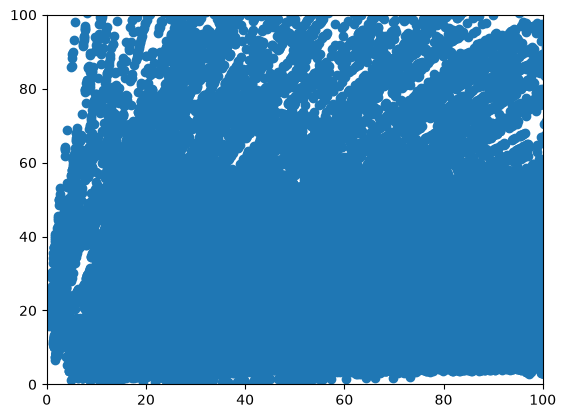

In [47]:
px_mask = processed_df.columns.get_level_values(1).isin(["PX_LAST"])
px_only = processed_df.loc[:, px_mask]
px_only.columns = px_only.columns.droplevel(1)
px_only = px_only.rename_axis(("date")).reset_index()
px_long = px_only.melt(id_vars="date", var_name="ticker", value_name="price")

pe_only.columns = pe_only.columns.droplevel(1)
pe_only = pe_only.rename_axis("date").reset_index()

pe_long = pe_only.melt(id_vars="date", var_name="ticker", value_name="pe")
pe_px_long = px_long.merge(pe_long, how="left", on=["date", "ticker"])

# since we know the date and ticker for the lowest PE, we can scatter the plot then highlight the point out
import matplotlib.pyplot as plt
plt.scatter(x=pe_px_long["price"], y=pe_px_long["pe"])
plt.xlim(xmin=0, xmax=100)
plt.ylim(ymin=0, ymax=100)

In [48]:
# lowest average over the past year

pe_num = pe_only.iloc[-252:].apply(pd.to_numeric, errors="coerce")
pe_num.mean().min()

np.float64(5.3907396825396825)

In [49]:
pe_num.date = pd.to_datetime(pe_num.date)

In [50]:
idx = px_only.index[px_only.date==row]
low_pe = pd.DataFrame([px_only.loc[:, col[0]], 
                          px_only.loc[:, col[0]].shift(120),
                          pe_only.loc[:, col[0]], 
                          pe_only.loc[:, col[0]].shift(120)]).transpose()
low_pe.columns = ["close", "shifted_close", "pe", "shifted_pe"]

low_pe.head()

,close,shifted_close,pe,shifted_pe
0,17.7720,NaN,51.4561,NaN
1,17.1114,NaN,49.5436,NaN
2,17.4889,NaN,50.6364,NaN
3,16.8283,NaN,48.7239,NaN
4,17.7711,NaN,51.4537,NaN


In [51]:
import numpy as np

low_pe["earnings"] = low_pe["close"]/low_pe["pe"]
low_pe["shifted_earnings"] = low_pe["earnings"].shift(120)
log_low_pe = np.log(low_pe)
log_low_pe

,close,shifted_close,pe,shifted_pe,earnings,shifted_earnings
0,2.877624,NaN,3.940729,NaN,-1.063105,NaN
1,2.839745,NaN,3.902853,NaN,-1.063108,NaN
2,2.861566,NaN,3.924671,NaN,-1.063104,NaN
3,2.823062,NaN,3.886170,NaN,-1.063108,NaN
4,2.877574,NaN,3.940682,NaN,-1.063109,NaN
...,...,...,...,...,...,...
570,4.861362,3.914139,3.071767,2.530581,1.789595,1.383558
571,4.832067,3.907372,3.042473,2.523815,1.789594,1.383557
572,4.905719,4.002770,3.116125,2.619212,1.789594,1.383558
573,5.006359,4.071258,3.216766,2.687705,1.789594,1.383554


In [52]:
# lsit = log_low_pe.index[log_low_pe["earnings"].isna()]
filled_earnings = log_low_pe["earnings"].ffill()
filled_earnings[140:150]

140   -1.383441
141   -1.383441
142   -1.383441
143   -0.747513
144   -0.747509
145   -0.747512
146   -0.747510
147   -0.747508
148   -0.747512
149   -0.747510
Name: earnings, dtype: float64

In [53]:
log_low_pe.earnings = log_low_pe.earnings.ffill()
log_low_pe.shifted_earnings = log_low_pe.earnings.shift(120)
log_low_pe.pe = log_low_pe.close-log_low_pe.earnings
log_low_pe.shifted_pe = log_low_pe.pe.shift(120)

lowest_point = log_low_pe.loc[idx]

close_contri = (lowest_point.close-lowest_point.shifted_close).values[0]
earnings_contri = (lowest_point.earnings-lowest_point.shifted_earnings).values[0]
print(f"close contributed the total of {close_contri/(close_contri-earnings_contri)*100:.2f}% of the chagne in PE")
print(f"while earnings contributed the total of {-earnings_contri/(close_contri-earnings_contri)*100:.2f}% of the chagne in PE")

close contributed the total of 3.35% of the chagne in PE
while earnings contributed the total of 96.65% of the chagne in PE


### A value strategy

In [126]:
# pe_only = pe_only.set_index("date", drop=True)
pe_rank = pe_only.rank(axis=1,pct=True)
weight = (pe_rank<0.2).astype(float)*0.01
weight

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2015-07-03,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.01,...,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.00
2015-07-10,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.01,...,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.00
2015-07-17,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.01,...,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.00
2015-07-24,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.01,...,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.00
2015-07-31,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.01,...,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-05,0.0,0.0,0.0,0.0,0.0,0.01,0.01,0.01,0.0,0.00,...,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.01
2026-06-12,0.0,0.0,0.0,0.0,0.0,0.01,0.01,0.01,0.0,0.00,...,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.01
2026-06-19,0.0,0.0,0.0,0.0,0.0,0.01,0.01,0.01,0.0,0.00,...,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.01


In [132]:
# now we have weights for the selected stocks, just time them with the return
# px_only = px_only.set_index("date", drop=True)
ret = px_only.pct_change()
shifted_ret = ret.shift(-1)

# now calculate the return for each holding
long_realiezd_return = shifted_ret*weight
long_total_return = long_realiezd_return.sum(axis=1)
long_final = (long_total_return+1).cumprod().iloc[-1]
print(f"{long_final*100:.2f}%")

512.02%


In [133]:
long_total_return.sum()

1.865730225937413

In [58]:
# what about a long-short strategy

long = (pe_rank<0.2).astype(float)*0.01
short = (pe_rank>0.8).astype(float)*(-0.01)
long_short = long+short

ls_realized_return = long_short*shifted_ret
ls_total_return = ls_realized_return.sum(axis=1)
ls_final=(ls_total_return+1).cumprod().iloc[-1]
ls_final
# print(f"the total return over the span of {px_only.shape[0]} weeks from {str(px_only.index.values[0]).split("T")[0]} to {str(px_only.index.values[-1]).split("T")[0]} is {ls_total_return*100:.2f}%")

0.9795881419449205

In [59]:
# calculate the perforamnce for long-short

ls_mean = ls_total_return.mean()
ls_vol = np.sqrt(ls_total_return.var())
ls_sharpe = ls_mean/ls_vol

print(f"the long short strategy offers mean of {ls_mean*100:.2f}% with standard deviation of {ls_vol*100:.2f}%, together makes the sharpe {ls_sharpe:.2f}")

the long short strategy offers mean of 0.01% with standard deviation of 1.85%, together makes the sharpe 0.01


In [60]:
etf_data = pd.read_excel("../data/spx_data_weekly.xlsx", sheet_name="additional data", header=None)
etf_data.head()

,0,1,2,3,4,5,6,7
0,NaN,SPY,IEF,IYR,GLD,USO,XBTUSD BGN Curncy,SHV
1,NaN,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST
2,date,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-07-03 00:00:00,172.8413,81.6517,51.8922,111.76,151.44,255.22,87.928
4,2015-07-10 00:00:00,172.983,81.6283,52.7649,111.49,141.36,287.13,87.928


In [61]:
tickers=list(etf_data.iloc[0, 1:])
etf = etf_data.iloc[3:]
etf.columns = ["date"] + tickers
etf = etf.set_index('date', drop=True)
etf.head()

,SPY,IEF,IYR,GLD,USO,XBTUSD BGN Curncy,SHV
date,,,,,,,
2015-07-03 00:00:00,172.8413,81.6517,51.8922,111.76,151.44,255.22,87.928
2015-07-10 00:00:00,172.983,81.6283,52.7649,111.49,141.36,287.13,87.928
2015-07-17 00:00:00,177.1517,81.9559,53.2083,108.65,135.92,278.27,87.9359
2015-07-24 00:00:00,173.4165,82.5332,52.8936,105.35,128.24,288.16,87.928
2015-07-31 00:00:00,175.5009,83.0325,53.523,104.93,124.72,284.69,87.912


In [62]:
## performance for spy

spy_ret = etf.SPY.pct_change()
mean = spy_ret.mean()
vol = spy_ret.std()
sharpe = mean/vol
print(mean)
print(vol)
print(sharpe)

0.002843280424747216
0.02341556138249611
0.12142695954634083


## Exercise 2: Attribution

In [63]:
long_total_return.head()

date
2015-07-03    -0.00193
2015-07-10    0.016649
2015-07-17   -0.016478
2015-07-24    0.013273
2015-07-31   -0.009116
dtype: object

In [64]:
long_total_return = long_total_return.dropna()
spy_ret = spy_ret.dropna()
intersection = long_total_return.index.intersection(spy_ret.index)
spy_for_long = spy_ret.loc[intersection]
long_for_lr = pd.DataFrame(long_total_return.loc[intersection])
long_model = LinearRegression().fit(long_for_lr, spy_for_long)

In [65]:
long_alpha=long_model.intercept_
long_beta=long_model.coef_
print(f"for long only, the alpha is {long_alpha}, the beta is {long_beta}")

for long only, the alpha is 0.003015410257030259, the beta is [-0.0586907]


In [66]:
etf.head()

,SPY,IEF,IYR,GLD,USO,XBTUSD BGN Curncy,SHV
date,,,,,,,
2015-07-03 00:00:00,172.8413,81.6517,51.8922,111.76,151.44,255.22,87.928
2015-07-10 00:00:00,172.983,81.6283,52.7649,111.49,141.36,287.13,87.928
2015-07-17 00:00:00,177.1517,81.9559,53.2083,108.65,135.92,278.27,87.9359
2015-07-24 00:00:00,173.4165,82.5332,52.8936,105.35,128.24,288.16,87.928
2015-07-31 00:00:00,175.5009,83.0325,53.523,104.93,124.72,284.69,87.912


In [67]:
etf.loc[:, etf.columns[~etf.columns.isin(["SPY", "SHV"])]]

,IEF,IYR,GLD,USO,XBTUSD BGN Curncy
date,,,,,
2015-07-03 00:00:00,81.6517,51.8922,111.76,151.44,255.22
2015-07-10 00:00:00,81.6283,52.7649,111.49,141.36,287.13
2015-07-17 00:00:00,81.9559,53.2083,108.65,135.92,278.27
2015-07-24 00:00:00,82.5332,52.8936,105.35,128.24,288.16
2015-07-31 00:00:00,83.0325,53.523,104.93,124.72,284.69
...,...,...,...,...,...
2026-06-12 00:00:00,93.8702,103.8599,386.54,125.43,63418.45
2026-06-19 00:00:00,94.0496,100.45,387.12,114.87,63200.01
2026-06-26 00:00:00,94.7174,104.64,373.63,105.48,59626.32


In [68]:
sector_etf_data = pd.read_excel("../data/spx_data_weekly.xlsx", sheet_name="sector data", header=None)

In [69]:
sector_etf_data.head()

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,NaN,XLK,NaN,XLI,NaN,XLF,NaN,XLC,NaN,XLRE,...,XLY,NaN,XLB,NaN,XLV,NaN,XLU,NaN,XLP,NaN
1,NaN,PX_LAST,EQY_DVD_YLD_IND,PX_LAST,EQY_DVD_YLD_IND,PX_LAST,EQY_DVD_YLD_IND,PX_LAST,EQY_DVD_YLD_IND,PX_LAST,...,PX_LAST,EQY_DVD_YLD_IND,PX_LAST,EQY_DVD_YLD_IND,PX_LAST,EQY_DVD_YLD_IND,PX_LAST,EQY_DVD_YLD_IND,PX_LAST,EQY_DVD_YLD_IND
2,date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-07-03 00:00:00,18.4255,2.0937,44.6636,2.4876,16.2666,2.7084,NaN,NaN,NaN,...,34.2521,1.4422,19.4423,2.3729,62.338,1.6774,14.8535,5.287,35.9255,3.359
4,2015-07-10 00:00:00,18.293,2.1089,44.6142,2.4903,16.2666,2.7084,NaN,NaN,NaN,...,34.4606,1.4335,19.1177,2.4132,62.7045,1.6676,15.1137,5.1959,36.6787,3.29


In [70]:
tickers = sector_etf_data.iloc[0].ffill()
fields = sector_etf_data.iloc[1]
sector_etf = sector_etf_data.iloc[3:].copy()
sector_etf.columns = pd.MultiIndex.from_arrays([tickers, fields])

cols = list(sector_etf.columns)
cols[0] = ("date", "date")
sector_etf.columns = pd.MultiIndex.from_tuples(cols)
sector_etf


date       XLK                       XLI                  \
                    date   PX_LAST EQY_DVD_YLD_IND   PX_LAST EQY_DVD_YLD_IND   
3    2015-07-03 00:00:00   18.4255          2.0937   44.6636          2.4876   
4    2015-07-10 00:00:00    18.293          2.1089   44.6142          2.4903   
5    2015-07-17 00:00:00   19.1759          2.0118   45.2319          2.4563   
6    2015-07-24 00:00:00   18.6991          2.0631   43.5682          2.5501   
7    2015-07-31 00:00:00   18.7963          2.0524   44.6554           2.488   
..                   ...       ...             ...       ...             ...   
573  2026-06-05 00:00:00  180.0853          0.3721  173.7524          1.0433   
574  2026-06-12 00:00:00  184.5799           0.363  175.7475          1.0315   
575  2026-06-19 00:00:00   191.212          0.4768  180.4659          0.9843   
576  2026-06-26 00:00:00    181.11          0.5034     181.2          0.9803   
577  2026-07-03 00:00:00    180.59          0.5048    183.91          0.9659   

         XLF                       XLC                     XLRE  ...  \
     PX_LAST EQY_DVD_YLD_IND   PX_LAST EQY_DVD_YLD_IND  PX_LAST  ...   
3    16.2666          2.7084       NaN             NaN      NaN  ...   
4    16.2666          2.7084       NaN             NaN      NaN  ...   
5    16.7618          2.6284       NaN             NaN      NaN  ...   
6    16.5835          2.6566       NaN             NaN      NaN  ...   
7    16.6429          2.6471       NaN             NaN      NaN  ...   
..       ...             ...       ...             ...      ...  ...   
573  52.1174          1.9302  111.3806          1.2823  44.3116  ...   
574  53.1537          1.8926  111.3606          1.2825  44.9658  ...   
575  53.3829          1.4018  109.1663          1.0397  43.4789  ...   
576    53.57          1.3969    106.18          1.0689    45.24  ...   
577    55.62          1.3454     109.6          1.0356    44.68  ...   

          XLY                      XLB                       XLV  \
      PX_LAST EQY_DVD_YLD_IND  PX_LAST EQY_DVD_YLD_IND   PX_LAST   
3     34.2521          1.4422  19.4423          2.3729    62.338   
4     34.4606          1.4335  19.1177          2.4132   62.7045   
5     35.1173          1.4067  19.1016          2.4152   64.1122   
6     34.9842           1.412  18.0676          2.5534   62.3464   
7      35.592          1.3879  18.4163          2.5051   63.7957   
..        ...             ...      ...             ...       ...   
573  114.6313          0.7524  50.4412          1.6517  152.3378   
574  116.3678          0.7412  51.9854          1.6027  153.1343   
575  116.9267          0.7978  51.6167          1.4975  148.7437   
576    114.37          0.8157     51.6           1.498    160.34   
577    117.12          0.7965    52.01          1.4862    163.74   

                         XLU                      XLP                  
    EQY_DVD_YLD_IND  PX_LAST EQY_DVD_YLD_IND  PX_LAST EQY_DVD_YLD_IND  
3            1.6774  14.8535           5.287  35.9255           3.359  
4            1.6676  15.1137          5.1959  36.6787            3.29  
5             1.631  15.2474          5.1504  37.3425          3.2315  
6            1.6771  14.8886          5.2745  37.0516          3.2569  
7             1.639  15.4725          5.0755  37.5215          3.2161  
..              ...      ...             ...      ...             ...  
573          1.5615  44.0682          2.8133  82.8648          2.1958  
574          1.5534  44.2471          2.8019  85.2284          2.1349  
575          1.7648  44.4756          2.5579  82.7258          2.7763  
576          1.6372     46.2          2.4625    84.71          2.7113  
577          1.6032    45.76          2.4861    84.99          2.7024  

[575 rows x 23 columns]

In [71]:
sector_etf_px = sector_etf.set_index(("date", "date"), drop=True)
cols = [col for col in sector_etf.columns if col[1]=="PX_LAST"]
sector_etf_px = sector_etf_px.loc[:, cols]
sector_etf_ret = sector_etf_px.pct_change()
sector_etf_ret

,XLK,XLI,XLF,XLC,XLRE,XLE,XLY,XLB,XLV,XLU,XLP
,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST
"(date, date)",,,,,,,,,,,
2015-07-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-10 00:00:00,-0.007191,-0.001106,0.0,NaN,NaN,-0.013956,0.006087,-0.016696,0.005879,0.017518,0.020966
2015-07-17 00:00:00,0.048264,0.013845,0.030443,NaN,NaN,-0.014288,0.019057,-0.000842,0.02245,0.008846,0.018098
2015-07-24 00:00:00,-0.024865,-0.036782,-0.010637,NaN,NaN,-0.040445,-0.00379,-0.054132,-0.027542,-0.023532,-0.00779
2015-07-31 00:00:00,0.005198,0.024954,0.003582,NaN,NaN,-0.001874,0.017374,0.0193,0.023246,0.039218,0.012682
...,...,...,...,...,...,...,...,...,...,...,...
2026-06-05 00:00:00,-0.05612,0.006065,0.013959,-0.034747,0.016142,0.024515,-0.049723,-0.010165,0.023683,-0.001577,0.006392
2026-06-12 00:00:00,0.024958,0.011482,0.019884,-0.00018,0.014764,-0.00208,0.015149,0.030614,0.005229,0.00406,0.028524


In [72]:
# assumption: fill nas with mean value

sector_etf_ret = sector_etf_ret.fillna(sector_etf_ret.mean(axis=0))
long_total_return = long_total_return.dropna()
intersection = long_total_return.index.intersection(sector_etf_ret.index)
sector_for_long = sector_etf_ret.loc[intersection]
long_for_lr = pd.DataFrame(long_total_return.loc[intersection])
long_model = LinearRegression().fit(sector_for_long, long_for_lr)

In [73]:
long_alpha=long_model.intercept_
long_beta=long_model.coef_
print(f"for long only, the alpha is {long_alpha}, the beta is {long_beta}")

for long only, the alpha is [0.00353661], the beta is [[-0.05172773  0.05684791 -0.05201477  0.0487415  -0.20067195 -0.00926267
   0.03413821  0.11314316  0.00541922 -0.05962104 -0.01698939]]


In [74]:
# sector_etf_ret.std()*np.array(long_beta)
sector_etf_ret.std()*long_beta.flatten()

XLK   PX_LAST   -0.001568
XLI   PX_LAST    0.001567
XLF   PX_LAST   -0.001569
XLC   PX_LAST    0.001159
XLRE  PX_LAST   -0.005764
XLE   PX_LAST   -0.000372
XLY   PX_LAST    0.001004
XLB   PX_LAST    0.003231
XLV   PX_LAST    0.000127
XLU   PX_LAST   -0.001564
XLP   PX_LAST   -0.000332
dtype: object

## 3. Extra considerations

In [75]:
px_only

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2015-07-03,36.1871,28.2065,43.5502,NaN,40.0398,21.6742,79.5735,80.75,51.7688,35.1247,...,20.727,89.654,23.3096,51.9923,31.9904,NaN,53.5097,95.8138,112.43,44.1218
2015-07-10,36.0225,27.5016,44.2014,NaN,40.4612,21.9975,80.759,80.59,49.461,34.085,...,20.3689,89.9657,23.828,51.417,30.8233,NaN,53.1064,94.5917,109.75,42.8888
2015-07-17,36.5253,28.9159,45.0183,NaN,40.6322,21.9658,82.1488,82.1,50.2249,34.6698,...,19.8416,88.0694,23.9346,51.6609,31.1891,NaN,51.5946,95.2028,114.18,43.656
2015-07-24,35.9402,27.7737,43.7898,NaN,41.5686,22.2732,82.713,80.98,47.0326,34.0706,...,19.3794,88.6929,23.338,49.9912,30.1614,NaN,50.9077,94.4589,110.89,45.1995
2015-07-31,37.4396,27.0599,45.0312,NaN,41.2754,22.6187,84.299,81.99,46.9039,34.2366,...,19.9783,89.3856,24.6235,49.5347,30.0743,NaN,51.5242,92.1651,107.63,44.7337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-05,135.18,307.34,227.23,133.54,91.07,91.19,176.1322,251.44,401.39,80.92,...,24.48,104.48,78.4489,149.92,109.94,68.15,150.87,87.0986,232.11,79.44
2026-06-12,129.5907,291.13,227.73,132.28,88.18,91.66,168.2569,204.02,417.79,80.24,...,24.85,107.27,78.6275,147.01,110.08,69.52,154.31,88.3353,228.42,79.57
2026-06-19,126.816,298.01,216.49,142.41,88.41,91.18,126.4595,195.16,434.46,75.1,...,24.32,105.53,77.41,137.81,111.42,74.78,151.99,87.7369,235.98,78.71


In [93]:
equity2 = pd.read_excel("../data/spx_data_weekly.xlsx", sheet_name="spx data", header=None)
equity2.iloc[0] = equity2.iloc[0].ffill()
equity2.loc[:, equity2.iloc[1].isin(["EQY_DVD_YLD_IND"])]



,2,5,8,11,14,17,20,23,26,29,...,1481,1484,1487,1490,1493,1496,1499,1502,1505,1508
0,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
1,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,...,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND,EQY_DVD_YLD_IND
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.1054,1.8435,4.6843,NaN,2.3976,NaN,2.5637,NaN,3.0907,3.1886,...,5.5966,2.2308,5.4913,5.6162,1.7605,NaN,3.0649,0.9184,NaN,0.7525
4,1.1104,1.8908,4.6152,NaN,2.3726,NaN,2.526,NaN,3.2349,3.2859,...,5.695,2.2231,5.3718,5.6791,1.8272,NaN,3.0881,0.9303,NaN,0.7741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,0.7545,0.3514,3.0454,NaN,2.7671,NaN,3.7018,NaN,1.0962,2.5704,...,3.4314,0.9571,3.0211,2.7481,1.5645,NaN,1.9885,1.1022,NaN,2.6687
574,0.7871,0.371,3.0387,NaN,2.8578,NaN,3.875,NaN,1.0532,2.5922,...,3.3803,0.9322,3.0142,2.8025,1.5625,NaN,1.9441,1.0868,NaN,2.6643
575,0.8043,0.3624,3.1965,NaN,2.8504,NaN,5.1558,NaN,1.0128,2.7696,...,3.4539,0.9476,3.0616,2.9896,1.5437,NaN,1.9738,1.0942,NaN,2.6934
576,0.7514,0.3806,2.7314,NaN,2.6774,NaN,5.1158,NaN,1.1372,2.7087,...,3.3188,0.9956,2.8822,3.0174,1.477,NaN,1.918,1.0311,NaN,2.7862


In [94]:
equity2.head()

,0,1,2,3,4,5,6,7,8,9,...,1500,1501,1502,1503,1504,1505,1506,1507,1508,1509
0,NaN,A,A,A,AAPL,AAPL,AAPL,ABBV,ABBV,ABBV,...,YUM,ZBH,ZBH,ZBH,ZBRA,ZBRA,ZBRA,ZTS,ZTS,ZTS
1,NaN,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,...,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO
2,date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-07-03 00:00:00,36.1871,1.1054,27.308,28.2065,1.8435,13.035,43.5502,4.6843,11.7314,...,18.4056,95.8138,0.9184,18.1514,112.43,NaN,151.5166,44.1218,0.7525,26.5871
4,2015-07-10 00:00:00,36.0225,1.1104,27.1839,27.5016,1.8908,12.7092,44.2014,4.6152,11.9068,...,18.2669,94.5917,0.9303,17.9199,109.75,NaN,147.9049,42.8888,0.7741,25.8441


In [106]:
div_only = equity2.iloc[2:].copy()
cols = [(equity2.iloc[0, i], equity2.iloc[1, i]) for i in range(equity2.shape[1])]
cols[0] = ("date", "date")
div_only.columns = pd.MultiIndex.from_tuples(cols)
div_only.head()

date        A                              AAPL  \
                  date  PX_LAST EQY_DVD_YLD_IND PE_RATIO  PX_LAST   
2                 date      NaN             NaN      NaN      NaN   
3  2015-07-03 00:00:00  36.1871          1.1054   27.308  28.2065   
4  2015-07-10 00:00:00  36.0225          1.1104  27.1839  27.5016   
5  2015-07-17 00:00:00  36.5253          1.0951  27.5633  28.9159   
6  2015-07-24 00:00:00  35.9402           1.113  27.1218  27.7737   

                               ABBV                           ...      YUM  \
  EQY_DVD_YLD_IND PE_RATIO  PX_LAST EQY_DVD_YLD_IND PE_RATIO  ... PE_RATIO   
2             NaN      NaN      NaN             NaN      NaN  ...      NaN   
3          1.8435   13.035  43.5502          4.6843  11.7314  ...  18.4056   
4          1.8908  12.7092  44.2014          4.6152  11.9068  ...  18.2669   
5          1.7983  13.3628  45.0183          4.5315  12.1268  ...  17.7469   
6          1.8723   12.835  43.7898          4.6586  11.7959  ...  17.5106   

       ZBH                             ZBRA                            \
   PX_LAST EQY_DVD_YLD_IND PE_RATIO PX_LAST EQY_DVD_YLD_IND  PE_RATIO   
2      NaN             NaN      NaN     NaN             NaN       NaN   
3  95.8138          0.9184  18.1514  112.43             NaN  151.5166   
4  94.5917          0.9303  17.9199  109.75             NaN  147.9049   
5  95.2028          0.9243  18.0356  114.18             NaN   153.875   
6  94.4589          0.9316  17.8947  110.89             NaN  149.4412   

       ZTS                           
   PX_LAST EQY_DVD_YLD_IND PE_RATIO  
2      NaN             NaN      NaN  
3  44.1218          0.7525  26.5871  
4  42.8888          0.7741  25.8441  
5   43.656          0.7605  26.3064  
6  45.1995          0.7345  27.2365  

[5 rows x 1510 columns]

In [ ]:
div_only = div_only.loc[:, div_only.columns.get_level_values(1).isin(["date", "EQY_DVD_YLD_IND"])]
div_only = div_only.droplevel(1, axis=1)
div_only

,date,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
2,date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-07-03 00:00:00,1.1054,1.8435,4.6843,NaN,2.3976,NaN,2.5637,NaN,3.0907,...,5.5966,2.2308,5.4913,5.6162,1.7605,NaN,3.0649,0.9184,NaN,0.7525
4,2015-07-10 00:00:00,1.1104,1.8908,4.6152,NaN,2.3726,NaN,2.526,NaN,3.2349,...,5.695,2.2231,5.3718,5.6791,1.8272,NaN,3.0881,0.9303,NaN,0.7741
5,2015-07-17 00:00:00,1.0951,1.7983,4.5315,NaN,2.3627,NaN,2.4833,NaN,3.1857,...,5.8463,2.2709,5.3479,5.6522,1.8058,NaN,3.1786,0.9243,NaN,0.7605
6,2015-07-24 00:00:00,1.113,1.8723,4.6586,NaN,2.3094,NaN,2.4664,NaN,3.4019,...,5.9857,2.255,5.4846,5.841,1.8673,NaN,3.2215,0.9316,NaN,0.7345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,2026-06-05 00:00:00,0.7545,0.3514,3.0454,NaN,2.7671,NaN,3.7018,NaN,1.0962,...,3.4314,0.9571,3.0211,2.7481,1.5645,NaN,1.9885,1.1022,NaN,2.6687
574,2026-06-12 00:00:00,0.7871,0.371,3.0387,NaN,2.8578,NaN,3.875,NaN,1.0532,...,3.3803,0.9322,3.0142,2.8025,1.5625,NaN,1.9441,1.0868,NaN,2.6643
575,2026-06-19 00:00:00,0.8043,0.3624,3.1965,NaN,2.8504,NaN,5.1558,NaN,1.0128,...,3.4539,0.9476,3.0616,2.9896,1.5437,NaN,1.9738,1.0942,NaN,2.6934
576,2026-06-26 00:00:00,0.7514,0.3806,2.7314,NaN,2.6774,NaN,5.1158,NaN,1.1372,...,3.3188,0.9956,2.8822,3.0174,1.477,NaN,1.918,1.0311,NaN,2.7862


In [110]:
# div_only = div_only.set_index("date")
div_only = div_only.iloc[1:]
div_only

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2015-07-03 00:00:00,1.1054,1.8435,4.6843,NaN,2.3976,NaN,2.5637,NaN,3.0907,3.1886,...,5.5966,2.2308,5.4913,5.6162,1.7605,NaN,3.0649,0.9184,NaN,0.7525
2015-07-10 00:00:00,1.1104,1.8908,4.6152,NaN,2.3726,NaN,2.526,NaN,3.2349,3.2859,...,5.695,2.2231,5.3718,5.6791,1.8272,NaN,3.0881,0.9303,NaN,0.7741
2015-07-17 00:00:00,1.0951,1.7983,4.5315,NaN,2.3627,NaN,2.4833,NaN,3.1857,3.2305,...,5.8463,2.2709,5.3479,5.6522,1.8058,NaN,3.1786,0.9243,NaN,0.7605
2015-07-24 00:00:00,1.113,1.8723,4.6586,NaN,2.3094,NaN,2.4664,NaN,3.4019,3.2873,...,5.9857,2.255,5.4846,5.841,1.8673,NaN,3.2215,0.9316,NaN,0.7345
2015-07-31 00:00:00,1.0684,1.9217,4.5302,NaN,2.3258,NaN,2.42,NaN,3.4112,3.2714,...,5.8063,2.2375,5.1983,5.8949,1.8727,NaN,3.183,0.9548,NaN,0.7422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-05 00:00:00,0.7545,0.3514,3.0454,NaN,2.7671,NaN,3.7018,NaN,1.0962,2.5704,...,3.4314,0.9571,3.0211,2.7481,1.5645,NaN,1.9885,1.1022,NaN,2.6687
2026-06-12 00:00:00,0.7871,0.371,3.0387,NaN,2.8578,NaN,3.875,NaN,1.0532,2.5922,...,3.3803,0.9322,3.0142,2.8025,1.5625,NaN,1.9441,1.0868,NaN,2.6643
2026-06-19 00:00:00,0.8043,0.3624,3.1965,NaN,2.8504,NaN,5.1558,NaN,1.0128,2.7696,...,3.4539,0.9476,3.0616,2.9896,1.5437,NaN,1.9738,1.0942,NaN,2.6934


In [112]:
cols = px_only.columns.intersection(div_only.columns)
div_only = div_only.loc[:, cols]
div_only.head()

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2015-07-03 00:00:00,1.1054,1.8435,4.6843,NaN,2.3976,NaN,2.5637,NaN,3.0907,3.1886,...,5.5966,2.2308,5.4913,5.6162,1.7605,NaN,3.0649,0.9184,NaN,0.7525
2015-07-10 00:00:00,1.1104,1.8908,4.6152,NaN,2.3726,NaN,2.526,NaN,3.2349,3.2859,...,5.695,2.2231,5.3718,5.6791,1.8272,NaN,3.0881,0.9303,NaN,0.7741
2015-07-17 00:00:00,1.0951,1.7983,4.5315,NaN,2.3627,NaN,2.4833,NaN,3.1857,3.2305,...,5.8463,2.2709,5.3479,5.6522,1.8058,NaN,3.1786,0.9243,NaN,0.7605
2015-07-24 00:00:00,1.113,1.8723,4.6586,NaN,2.3094,NaN,2.4664,NaN,3.4019,3.2873,...,5.9857,2.255,5.4846,5.841,1.8673,NaN,3.2215,0.9316,NaN,0.7345
2015-07-31 00:00:00,1.0684,1.9217,4.5302,NaN,2.3258,NaN,2.42,NaN,3.4112,3.2714,...,5.8063,2.2375,5.1983,5.8949,1.8727,NaN,3.183,0.9548,NaN,0.7422


In [115]:
div_rk = div_only.rank(axis=1, pct=True)
div_weight = (div_rk>0.8).astype(float)*0.01
div_weight

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2015-07-03 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.01,0.0,0.01,0.01,0.0,0.0,0.0,0.0,0.0,0.0
2015-07-10 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.01,0.0,0.01,0.01,0.0,0.0,0.0,0.0,0.0,0.0
2015-07-17 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.01,0.0,0.01,0.01,0.0,0.0,0.0,0.0,0.0,0.0
2015-07-24 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.01,0.0,0.01,0.01,0.0,0.0,0.0,0.0,0.0,0.0
2015-07-31 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.01,0.0,0.01,0.01,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-05 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,...,0.01,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0
2026-06-12 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,...,0.01,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0
2026-06-19 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,...,0.01,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0


In [120]:
ret = px_only.pct_change().shift(-1)
div_realized_ret = div_weight*ret
div_total_ret = div_realized_ret.sum(axis=1)
div_total_ret

date
2015-07-03 00:00:00    0.004272
2015-07-10 00:00:00    0.004778
2015-07-17 00:00:00   -0.015886
2015-07-24 00:00:00    0.016071
2015-07-31 00:00:00   -0.004796
                         ...   
2026-06-05 00:00:00    0.020896
2026-06-12 00:00:00   -0.025201
2026-06-19 00:00:00    0.025152
2026-06-26 00:00:00    0.004094
2026-07-03 00:00:00           0
Length: 575, dtype: object

In [122]:
div_mean = div_total_ret.mean()
div_vol = div_total_ret.std()
div_sharpe = div_mean/div_vol

print(f"mean: {div_mean:.2f}, volatility: {div_vol:.2f}, sharpe: {div_sharpe:.2f}")

mean: 0.00, volatility: 0.02, sharpe: 0.10


### 3.2 Improvements

Use sma to smooth the pe line could be a way to improve the signal stability

In [167]:
# first some metrices for long-only pe strategy

long_mean = long_total_return.mean()
long_vol = long_total_return.std()
long_sharpe = long_mean/long_vol

print(f"mean: {long_mean*100:.2f}%, volatility: {long_vol*100:.2f}%, sharpe: {long_sharpe:.2f}")

mean: 0.32%, volatility: 2.83%, sharpe: 0.11


In [169]:
pe_rk = pe_only.rank(axis=1, pct=True)
pe_rk
long = pe_rk[(pe_rk>0.8)].fillna(0)
long_weight = long.div(long.sum(axis=1), axis=0)*0.2
long_weight.head()

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2015-07-03,0.002121,0.0,0.0,0.0,0.0,0.0,0.0,0.002512,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002530,0.002068
2015-07-10,0.002104,0.0,0.0,0.0,0.0,0.0,0.0,0.002511,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002529,0.000000
2015-07-17,0.002104,0.0,0.0,0.0,0.0,0.0,0.0,0.002511,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002529,0.000000
2015-07-24,0.002110,0.0,0.0,0.0,0.0,0.0,0.0,0.002511,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002529,0.002116
2015-07-31,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.002504,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002522,0.002064


In [170]:
rewei_realized_ret = ret*long_weight
rewei_total_ret = rewei_realized_ret.sum(axis=1)

rewei_mean=rewei_total_ret.mean()
rewei_vol = rewei_total_ret.std()
rewei_sharpe = rewei_mean/rewei_vol

print(f"mean: {rewei_mean*100:.2f}%, volatility: {rewei_vol*100:.2f}%, sharpe: {rewei_sharpe:.2f}")

mean: 0.12%, volatility: 0.55%, sharpe: 0.21


# ETF Arbitrage

## 1. SPY Premium

In [1]:
import pandas as pd
import numpy as np

In [9]:
px = pd.read_excel("../data/etf_arb_data.xlsx", sheet_name="prices")
px.head()

,date,SPY,HYG,GBTC
0,2015-01-02,205.43,89.60,NaN
1,2015-01-05,201.72,88.77,NaN
2,2015-01-06,199.82,88.43,NaN
3,2015-01-07,202.31,88.98,NaN
4,2015-01-08,205.90,89.65,NaN


In [10]:
nav = pd.read_excel("../data/etf_arb_data.xlsx", sheet_name="nav")
nav.head()

,date,SPY,HYG,GBTC
0,2015-01-02,205.459,89.45,0.3030
1,2015-01-05,201.716,89.32,0.2603
2,2015-01-06,199.923,88.92,0.2673
3,2015-01-07,202.309,89.08,0.2792
4,2015-01-08,205.931,89.51,0.2792


In [11]:
px = px.set_index("date", drop=True)
nav = nav.set_index("date", drop=True)

In [12]:
ETFS = ["SPY", "HYG"]
px = px.loc[:, ETFS]
nav = nav.loc[:, ETFS]

In [13]:
px.head()

,SPY,HYG
date,,
2015-01-02,205.43,89.60
2015-01-05,201.72,88.77
2015-01-06,199.82,88.43
2015-01-07,202.31,88.98
2015-01-08,205.90,89.65


In [15]:
spy_px = px[["SPY"]]
spy_nav = nav[["SPY"]]
spy_data = spy_px.merge(spy_nav, left_index=True, right_index=True)
spy_data.head()

,SPY_x,SPY_y
date,,
2015-01-02,205.43,205.459
2015-01-05,201.72,201.716
2015-01-06,199.82,199.923
2015-01-07,202.31,202.309
2015-01-08,205.90,205.931


In [16]:
spy_data.columns = ["px", "nav"]
spy_data.head()

,px,nav
date,,
2015-01-02,205.43,205.459
2015-01-05,201.72,201.716
2015-01-06,199.82,199.923
2015-01-07,202.31,202.309
2015-01-08,205.90,205.931


In [19]:
spy_data["prem"] = (spy_data["px"]/spy_data["nav"]-1)*10000 #in basis points
spy_prem_mean = spy_data["prem"].mean()
spy_prem_vol = spy_data["prem"].std()
spy_prem_min = np.abs(spy_data["prem"]).min()
spy_prem_max = np.abs(spy_data["prem"]).max()
print(f"mean={spy_prem_mean:.2f} bps")
print(f"volatility={spy_prem_vol:.2f} bps")
print(f"min={spy_prem_min:.2f} bps")
print(f"max={spy_prem_max:.2f} bps")

mean=0.30 bps
volatility=4.23 bps
min=0.00 bps
max=90.04 bps


<Axes: xlabel='date'>

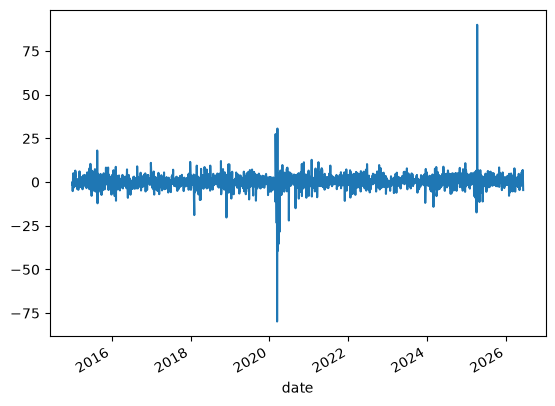

In [20]:
spy_data.prem.plot()

In [28]:
PREMIUM = 0.005
CREATION_UNIT = 5e4
spy_lat_nav = spy_data.loc[spy_data.index[-1], "nav"]
spy_lat_nav*(PREMIUM)*CREATION_UNIT

np.float64(184346.4)

In [30]:
CREATION_FEE = 3000
TRADING_COST = 0.0003

cost_prem = spy_lat_nav*TRADING_COST+CREATION_FEE
required_prem = cost_prem/(spy_lat_nav*CREATION_UNIT)
print(f"required {required_prem*10000} bps")

required 0.8137455398315345 bps


## 2. HYG in March 2020

In [31]:
hyg_px = px[["HYG"]]
hyg_nav = nav[["HYG"]]
hyg_data = hyg_px.merge(hyg_nav, left_index=True, right_index=True)
hyg_data.head()

,HYG_x,HYG_y
date,,
2015-01-02,89.60,89.45
2015-01-05,88.77,89.32
2015-01-06,88.43,88.92
2015-01-07,88.98,89.08
2015-01-08,89.65,89.51


In [32]:
hyg_data.columns = ["px", "nav"]
hyg_data["prem"] = hyg_data["px"]/hyg_data["nav"]-1
hyg_data.head()

,px,nav,prem
date,,,
2015-01-02,89.60,89.45,0.001677
2015-01-05,88.77,89.32,-0.006158
2015-01-06,88.43,88.92,-0.005511
2015-01-07,88.98,89.08,-0.001123
2015-01-08,89.65,89.51,0.001564


In [33]:
hyg_data.prem = hyg_data.prem*1e4 #to basis points
hyg_prem_mean = hyg_data["prem"].mean()
hyg_prem_vol = hyg_data["prem"].std()
hyg_prem_min = np.abs(hyg_data["prem"]).min()
hyg_prem_max = np.abs(hyg_data["prem"]).max()
print(f"mean={hyg_prem_mean:.2f} bps")
print(f"volatility={hyg_prem_vol:.2f} bps")
print(f"min={hyg_prem_min:.2f} bps")
print(f"max={hyg_prem_max:.2f} bps")

mean=20.95 bps
volatility=31.34 bps
min=0.00 bps
max=458.41 bps


<Axes: xlabel='date'>

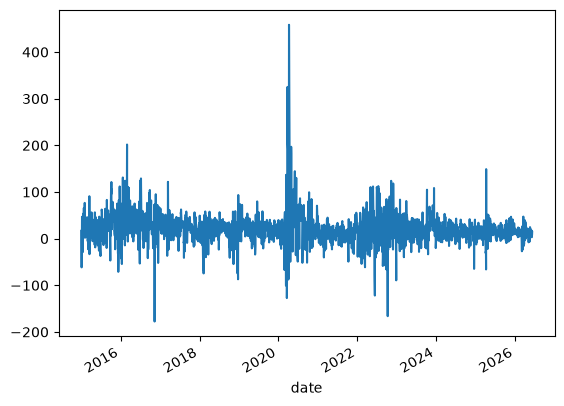

In [34]:
hyg_data.prem.plot()

In [35]:
# since it's a much less liquid basket, selling those bonds might push up the price and eventually make the price undesirable
# or even cannot sell all the bonds

<Axes: xlabel='date'>

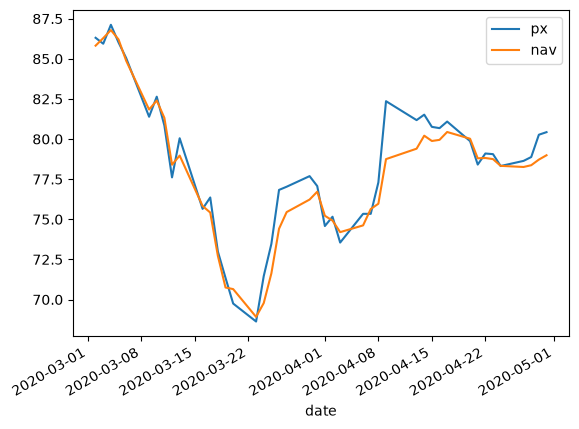

In [37]:
hyg_data.loc["2020-03":"2020-04", ["px", "nav"]].plot()

In [38]:
# it does look like hyg price has some level of predition power against the nav